# Part 2 — Dataset Visual Representation (EDA)
**Breast Cancer Wisconsin Diagnosis — Logistic Regression Project**

This notebook continues from Part 1 (Dataset Cleaning & Processing). The `ID` column has been dropped and `Diagnosis` has been label-encoded (`M` = 1 → Malignant, `B` = 0 → Benign). The goal here is to visually explore the dataset before it goes into model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


### Load the cleaned data
(Re-applying the two cleaning steps from Part 1 so this notebook can run standalone.)

In [2]:
df = pd.read_csv("wdbc_named.csv")
df = df.drop(columns=["ID"])
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})
df.head()


## 1. Target Class Distribution
Checking how balanced the dataset is between Benign (0) and Malignant (1) cases.

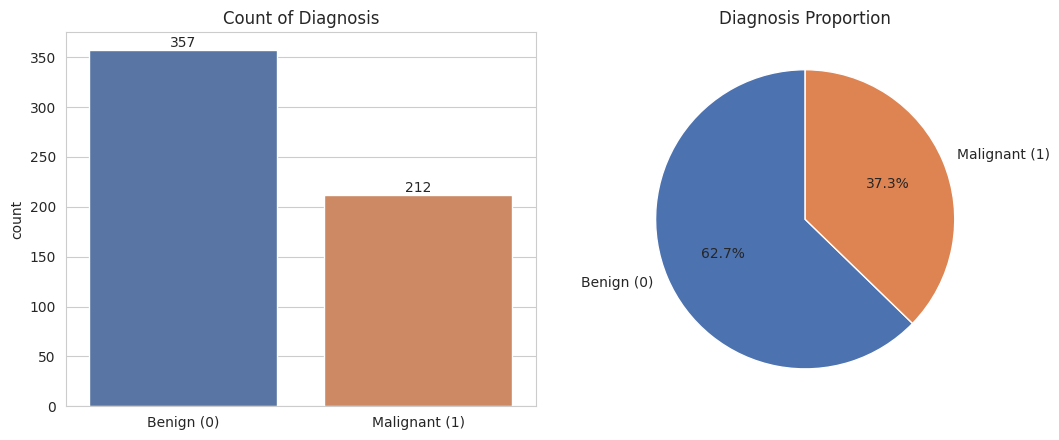

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
counts = df["Diagnosis"].value_counts().sort_index()
labels = ["Benign (0)", "Malignant (1)"]

sns.countplot(x="Diagnosis", data=df, ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_xticklabels(labels)
axes[0].set_title("Count of Diagnosis")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")

axes[1].pie(counts, labels=labels, autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Diagnosis Proportion")

fig.tight_layout()
plt.show()


**Observation:** 357 Benign vs 212 Malignant cases (62.7% / 37.3%). There's a moderate class imbalance — worth keeping in mind when training/evaluating the model (e.g. using stratified train/test split, and looking at precision/recall, not just accuracy).

## 2. Summary Statistics Grouped by Diagnosis
Comparing average feature values for Benign vs Malignant tumors (mean-type features).

In [4]:
grouped = df.groupby("Diagnosis")[mean_cols].mean().T
grouped.columns = ["Benign (0)", "Malignant (1)"]
grouped


                        Benign (0)  Malignant (1)
radius_mean                 12.147         17.463
texture_mean                17.915         21.605
perimeter_mean              78.075        115.365
area_mean                  462.790        978.376
smoothness_mean              0.092          0.103
compactness_mean             0.080          0.145
concavity_mean               0.046          0.161
concave_points_mean          0.026          0.088
symmetry_mean                0.174          0.193
fractal_dimension_mean       0.063          0.063

**Observation:** Malignant tumors have noticeably higher average `radius`, `perimeter`, `area`, `concavity`, and `concave points` compared to benign ones — these look like strong candidate features.

## 3. Distribution of Key Features by Diagnosis (Histograms)
Overlaying histograms for Benign vs Malignant across six of the most clinically relevant `_mean` features.

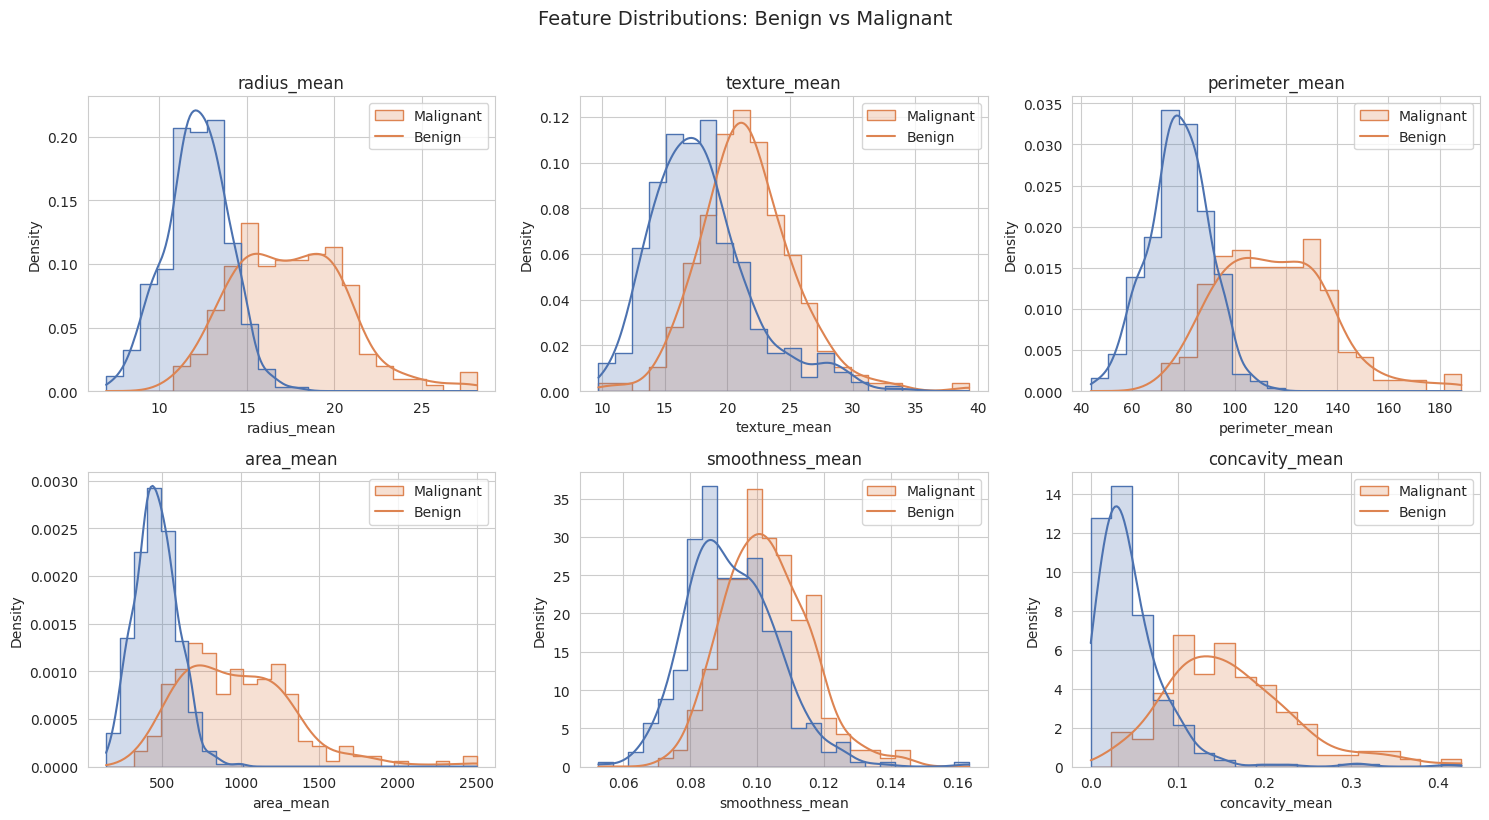

In [5]:
key_feats = ["radius_mean", "texture_mean", "perimeter_mean",
             "area_mean", "smoothness_mean", "concavity_mean"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_feats):
    sns.histplot(data=df, x=col, hue="Diagnosis", kde=True, ax=axes[i],
                 palette=["#4C72B0", "#DD8452"], element="step", stat="density", common_norm=False)
    axes[i].set_title(col)
    axes[i].legend(labels=["Malignant", "Benign"])

fig.suptitle("Feature Distributions: Benign vs Malignant", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## 4. Boxplots of Key Features by Diagnosis
Boxplots make it easier to spot separation between classes and outliers.

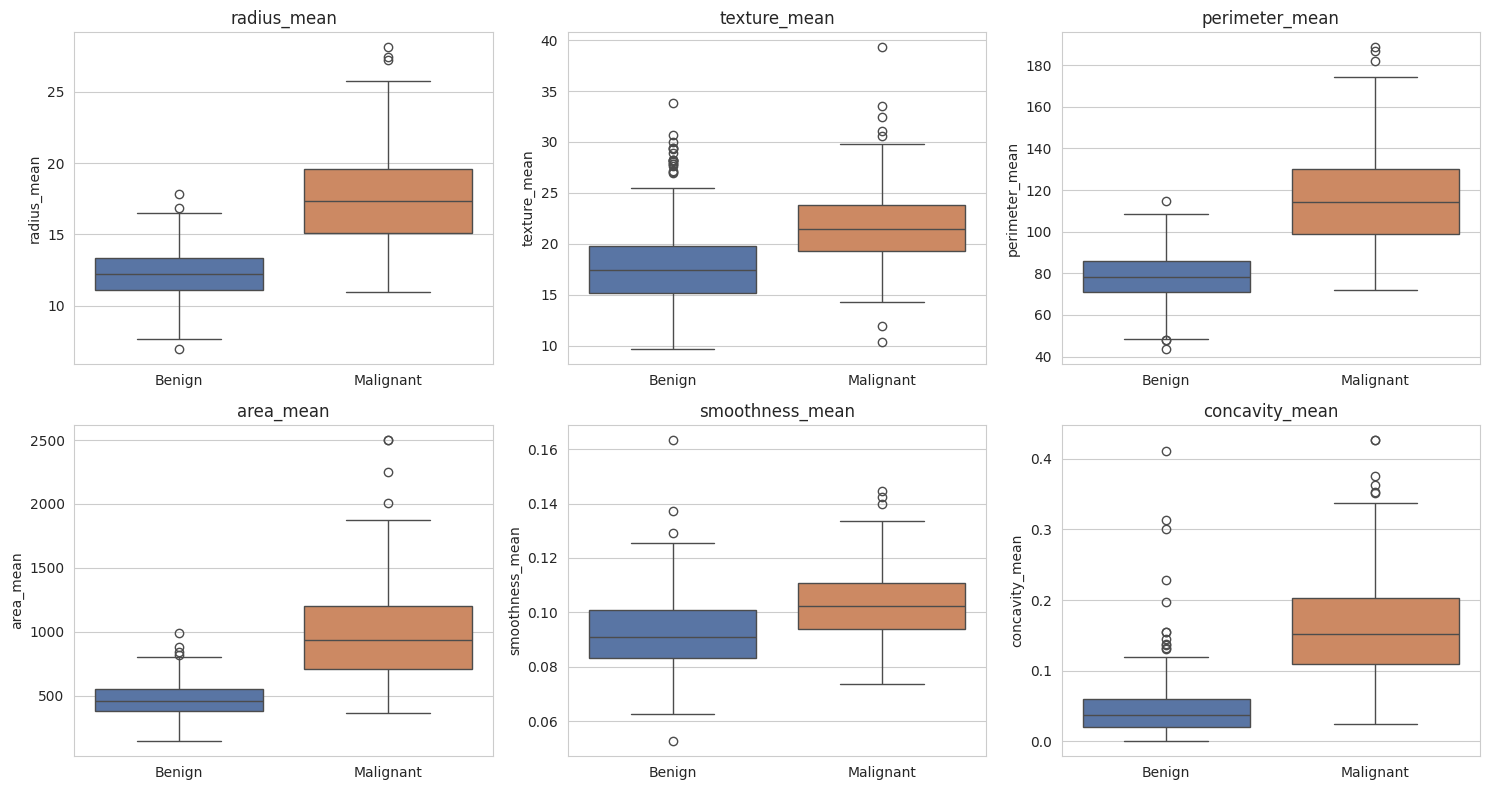

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_feats):
    sns.boxplot(data=df, x="Diagnosis", y=col, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_xticklabels(["Benign", "Malignant"])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

fig.tight_layout()
plt.show()


**Observation:** `radius_mean`, `perimeter_mean`, `area_mean`, and `concavity_mean` show clear separation between the two classes, with Malignant tumors consistently higher and more spread out.

## 5. Violin Plots — Texture & Smoothness
Violin plots show the full distribution shape (not just quartiles) split by diagnosis.

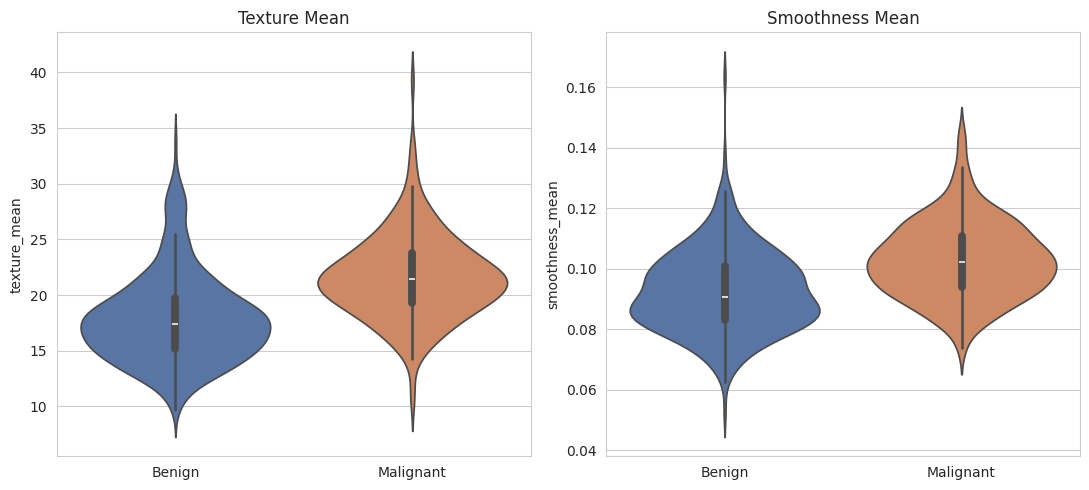

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.violinplot(data=df, x="Diagnosis", y="texture_mean", ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_xticklabels(["Benign", "Malignant"])
axes[0].set_title("Texture Mean")
axes[0].set_xlabel("")

sns.violinplot(data=df, x="Diagnosis", y="smoothness_mean", ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_xticklabels(["Benign", "Malignant"])
axes[1].set_title("Smoothness Mean")
axes[1].set_xlabel("")

fig.tight_layout()
plt.show()


## 6. Correlation Heatmap (All Features)
Checking pairwise correlation across all 30 numeric features plus the target.

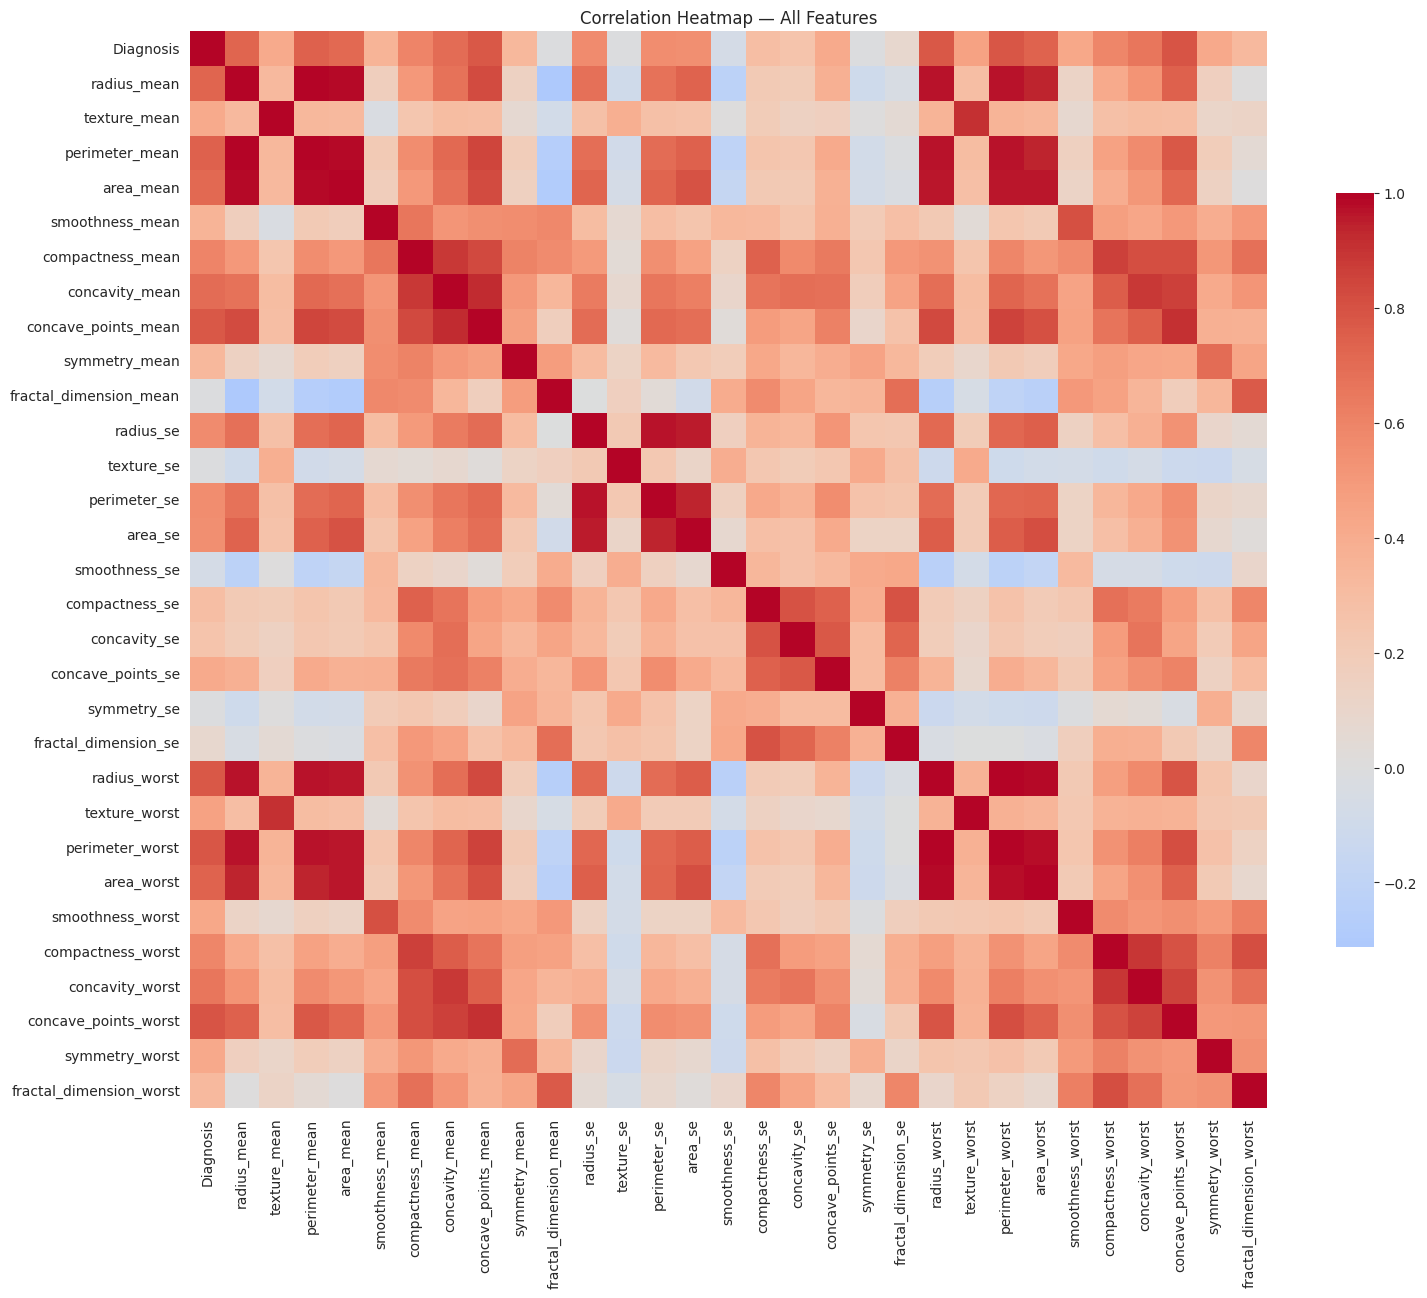

In [8]:
fig, ax = plt.subplots(figsize=(16, 13))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Heatmap — All Features")
fig.tight_layout()
plt.show()


**Observation:** Many `mean`, `se`, and `worst` versions of the same measurement are highly correlated with each other (e.g. `radius_mean` and `radius_worst`), which is expected — this is useful context for the modeling team when they consider multicollinearity in Logistic Regression.

## 7. Feature Correlation with Diagnosis (Target)
Ranking every feature by how strongly it correlates with the diagnosis label.

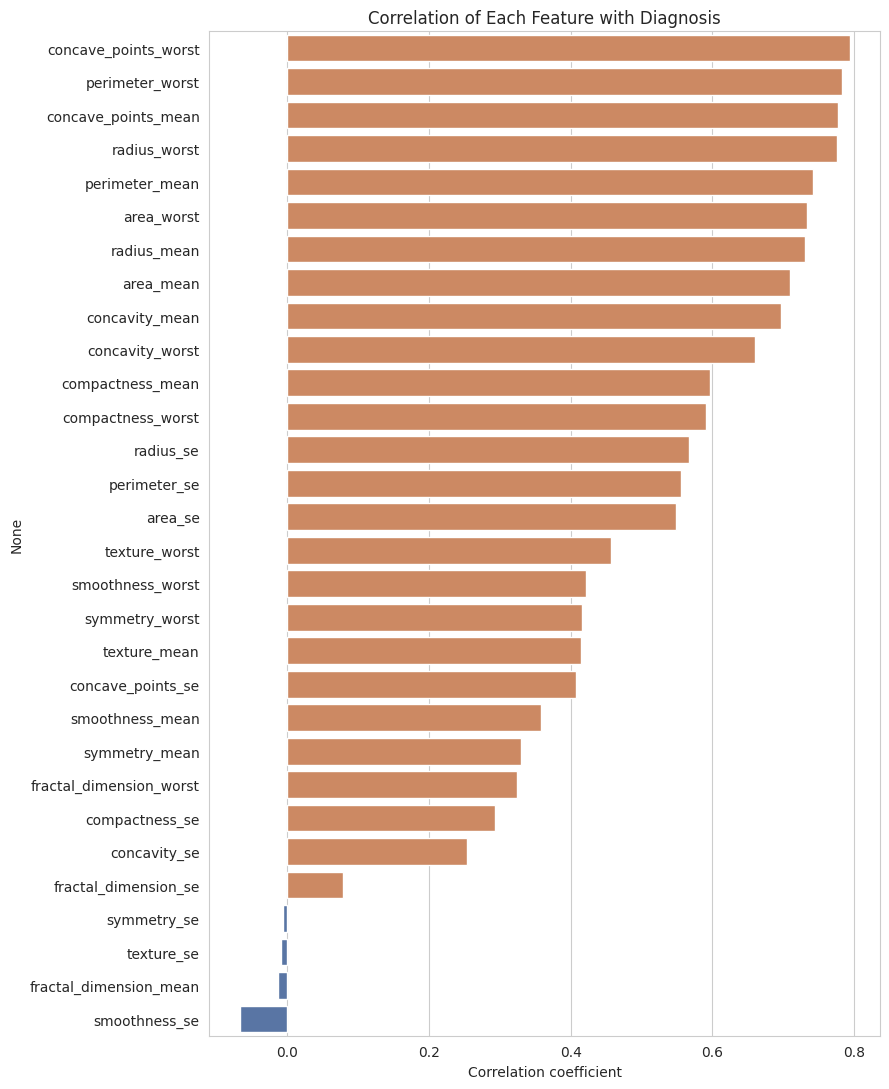

In [9]:
target_corr = df.corr()["Diagnosis"].drop("Diagnosis").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 11))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in target_corr.values]
sns.barplot(x=target_corr.values, y=target_corr.index, ax=ax, palette=colors)
ax.set_title("Correlation of Each Feature with Diagnosis")
ax.set_xlabel("Correlation coefficient")
fig.tight_layout()
plt.show()


**Top 5 most correlated features with Diagnosis:**

- `concave_points_worst`: 0.794
- `perimeter_worst`: 0.783
- `concave_points_mean`: 0.777
- `radius_worst`: 0.776
- `perimeter_mean`: 0.743

These are strong candidates for the model-training team to prioritize.

## 8. Pairplot of the Top 5 Correlated Features
Visualizing pairwise relationships and separability between classes for the strongest features.

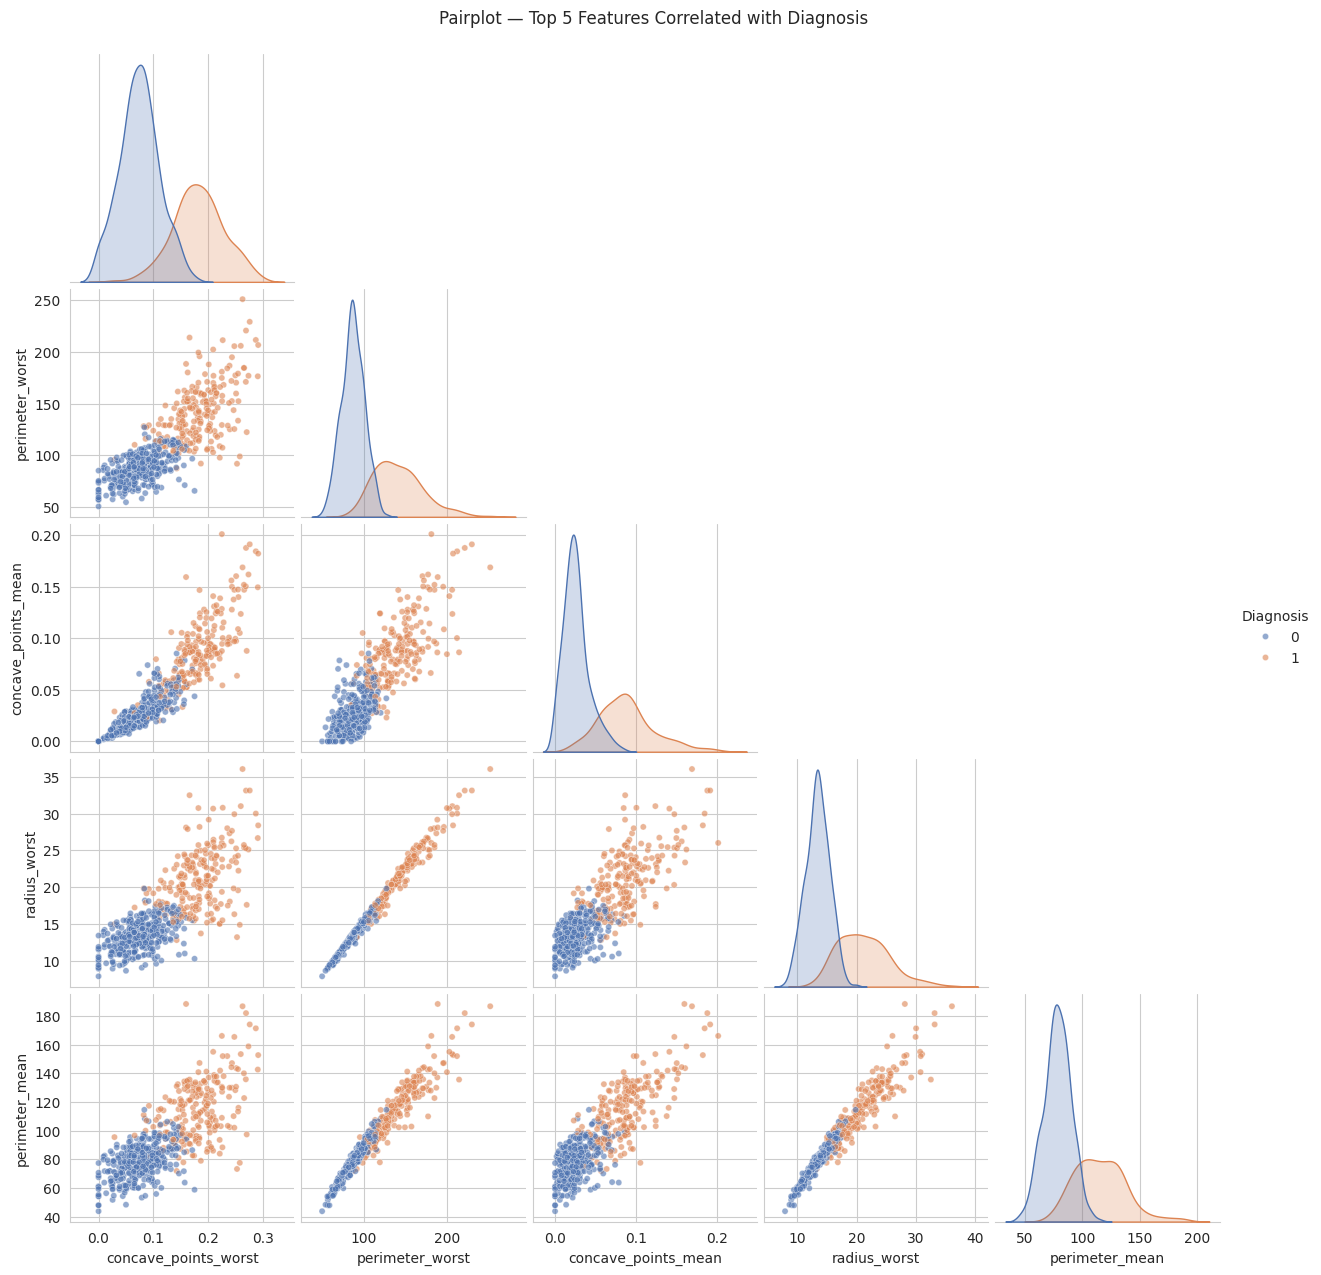

In [10]:
top5_feats = list(top5.index)
pp = sns.pairplot(df[top5_feats + ["Diagnosis"]], hue="Diagnosis",
                   palette=["#4C72B0", "#DD8452"], corner=True, plot_kws={"alpha": 0.6, "s": 20})
pp.fig.suptitle("Pairplot — Top 5 Features Correlated with Diagnosis", y=1.02)
plt.show()


## 9. Scatter Plot — Radius vs Concave Points
A closer look at the two strongest predictors, colored by diagnosis.

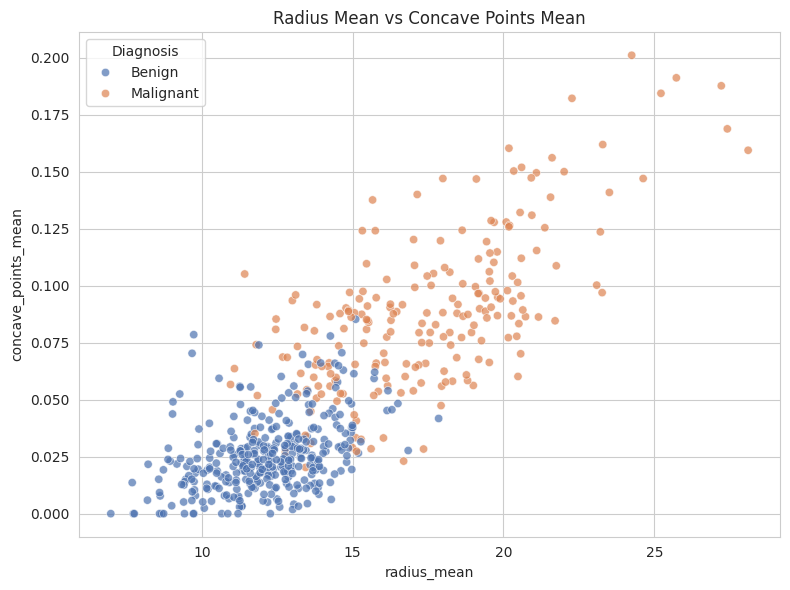

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="radius_mean", y="concave_points_mean", hue="Diagnosis",
                 palette=["#4C72B0", "#DD8452"], alpha=0.7, ax=ax)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Benign", "Malignant"], title="Diagnosis")
ax.set_title("Radius Mean vs Concave Points Mean")
fig.tight_layout()
plt.show()


**Observation:** There's fairly clear visual separation between Benign and Malignant points along these two features alone, which is a good sign for a linear model like Logistic Regression.

## Summary of EDA Findings

- The dataset has a moderate class imbalance (~63% Benign / 37% Malignant).
- `radius`, `perimeter`, `area`, `concavity`, and `concave points` (mean & worst variants) show the clearest separation between Benign and Malignant tumors.
- Several features are highly inter-correlated (mean/se/worst of the same measurement), which the model-training team should account for when interpreting Logistic Regression coefficients.
- No missing values were found (confirmed in Part 1), so no imputation is required before modeling.

*Next step: hand off to the model training team (Part 3) for train/test split, scaling, and Logistic Regression training.*